# Part 1: Getting started and setup


##  Task 1: Importing Libraries


In [2]:
# Import libaries
import cv2
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import gradio as gr  
from deoldify.visualize import *

warnings.filterwarnings("ignore")

## Task 2: Read Input Image


In [3]:
# Read your preferred image from the test cases

input_image = '/usercode/test_case_images/test_case_1.jpg'
grayscale_image = cv2.imread(input_image)

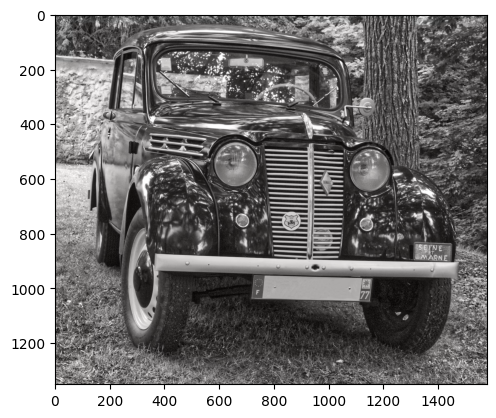

In [4]:
# Display the grayscale image
plt.imshow(grayscale_image, cmap='gray') 
plt.show()

# Part 2: Image Colorization using DeOldify


## Task 3: Colorize the Grayscale Image

In [5]:
# Create the function that will transform the grayscale image to beautiful colorized image
def colorize_image(input_image, render_factor):
    colorizer = get_image_colorizer()
    colorized_image = colorizer.get_transformed_image(input_image, render_factor=render_factor,watermarked=False)
    colorized_image = np.asarray(colorized_image)
    plt.imshow(colorized_image)

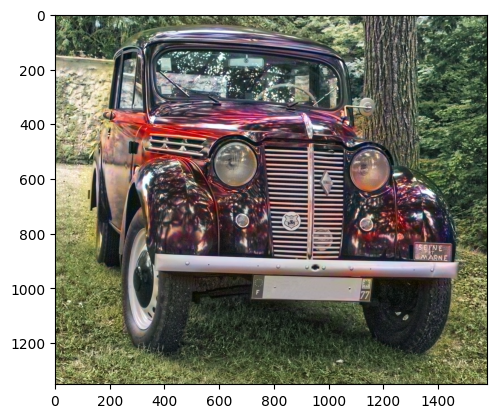

In [6]:
# Call the function to display the image
colorize_image(input_image,12)

## Task 4: Transform and Scale the Image


In [7]:
# Update the previous task function that will transform the grayscale image to beautiful colorized image to scale it to a suitable size
def colorize_image(input_image, render_factor):
    colorizer = get_image_colorizer()
    colorized_image = colorizer.get_transformed_image(input_image, render_factor=render_factor,watermarked=False)
    colorized_image = np.asarray(colorized_image)
    target_size = (int(colorized_image.shape[1] * 0.5), int(colorized_image.shape[0] * 0.5))
    height, width = colorized_image.shape[:2]
    scale_factor = min(target_size[0] / width, target_size[1] / height)  
    colorized_image = cv2.resize(colorized_image, None, fx=scale_factor, fy=scale_factor)
    return colorized_image

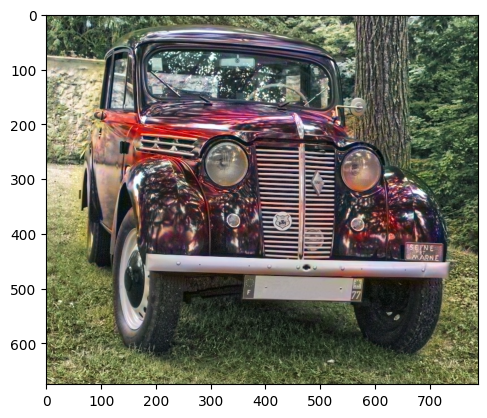

In [8]:
# Call the function and store it in variable and then display it

colorized_image=colorize_image(input_image,12)
plt.imshow(colorized_image)

## Task 5: Split Transformed Image into RGB Layers


In [9]:
# Create a function to split the colorized image and see it's RGB Channels
def RGB_layers_image(image,render_factor):
    colorized_image = colorize_image(image,render_factor)
    r,g,b = cv2.split(colorized_image)

    zeros = np.zeros(b.shape, np.uint8)
    r_colorized = cv2.merge((r,zeros,zeros))
    g_colorized = cv2.merge((zeros,g,zeros))
    b_colorized = cv2.merge((zeros,zeros,b))

    return [r_colorized, g_colorized, b_colorized]

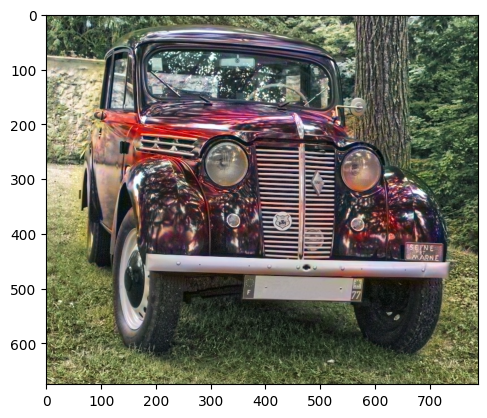

In [10]:
# Call RGB layers image function, store it's result in 3 variables and merge them by sum
r, g, b = RGB_layers_image(input_image,12)
image_merged = r + g + b
plt.imshow(image_merged)

## Task 6: Display RGB Channels and Merged Image with Matplotlib



In [11]:
# Create two lists, one for the images and other their titles and adjust the figure size
channels = [r, g, b, image_merged]
titles = ['Red Channel', 'Green Channel', 'Blue Channel', 'Merged Image']

plt.figure(figsize=(16, 8))

<Figure size 1600x800 with 0 Axes>

<Figure size 1600x800 with 0 Axes>

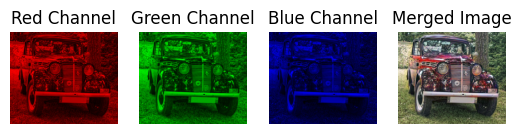

In [12]:
# Display all four images side by side using a for loop
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(channels[i])
    plt.title(titles[i])
    plt.axis('off')

plt.show()

# Part 4: Creating User-Friendly interface by Gradio


## Task 7: Load Sample Images


In [13]:
# Create a list comprehension to generate the file paths for the test cases images
import cv2
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import gradio as gr  
from deoldify.visualize import *

warnings.filterwarnings("ignore")

In [14]:
# Create the UI Gradio layout for interaction and component arrangement

examples = [f'/usercode/test_case_images/test_case_{i}.jpg' for i in range(1, 12)]

In [15]:
with gr.Blocks() as demo:
    with gr.Row():
        image = gr.Image(label="Image to Convert", show_label=True, type='filepath')
        slider = gr.Slider(minimum=7, maximum=40, value=12, step=1, label="Render factor", show_label=True)
    gr.Markdown("## Image Examples")
    gr.Examples(
          examples=examples,
          inputs=image,
      )
if __name__ == "__main__":
    demo.launch(debug=True, share=True, server_name="0.0.0.0", server_port=3000)   

HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
* Running on local URL:  http://0.0.0.0:3000
HTTP Request: GET http://localhost:3000/gradio_api/startup-events "HTTP/1.1 200 OK"
HTTP Request: HEAD http://localhost:3000/ "HTTP/1.1 200 OK"
HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"
* Running on public URL: https://7d9adbe346d8bc2df9.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
HTTP Request: HEAD https://7d9adbe346d8bc2df9.gradio.live "HTTP/1.1 200 OK"


Keyboard interruption in main thread... closing server.
Killing tunnel 0.0.0.0:3000 <> https://7d9adbe346d8bc2df9.gradio.live


## Task 8: Create Display Image Function


In [16]:
with gr.Blocks() as demo:
    with gr.Row():
        image = gr.Image(label="Image to Convert", show_label=True, type='filepath')
        slider = gr.Slider(minimum=7, maximum=40, value=12, step=1, label="Render factor", show_label=True)
    gr.Markdown("## Image Examples")
    gr.Examples(
          examples=examples,
          inputs=image,
      )

    btn_1 = gr.Button()
    rgb_gallery = gr.Gallery()

    btn_2 = gr.Button()
    colorized_image=gr.Image()

if __name__ == "__main__":
    demo.launch(debug=True, share=True, server_name="0.0.0.0", server_port=3000)   

HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
* Running on local URL:  http://0.0.0.0:3000
HTTP Request: GET http://localhost:3000/gradio_api/startup-events "HTTP/1.1 200 OK"
HTTP Request: HEAD http://localhost:3000/ "HTTP/1.1 200 OK"
HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"
* Running on public URL: https://9b3b210b7eb2e0079f.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
HTTP Request: HEAD https://9b3b210b7eb2e0079f.gradio.live "HTTP/1.1 200 OK"


Keyboard interruption in main thread... closing server.
Killing tunnel 0.0.0.0:3000 <> https://9b3b210b7eb2e0079f.gradio.live


## Task 9: Set Gradio Interface Parameters


In [17]:
# Set the buttons and displaying function parameters
with gr.Blocks() as demo:
    with gr.Row():
        image = gr.Image(label="Image to Convert", show_label=True, type='filepath')
        slider = gr.Slider(minimum=7, maximum=40, value=12, step=1, label="Render factor", show_label=True)

    gr.Markdown("## Image Examples")
    gr.Examples(
          examples=examples,
          inputs=image,
      )

    btn_1 = gr.Button(value="Get R G B Channels ", scale=2)
    rgb_gallery = gr.Gallery(label="Generated Images(RGB)", columns=[3], rows=[1], object_fit="contain", height="auto")


    btn_2 = gr.Button(value="Get colorized image", scale=2)
    colorized_image =gr.Image(label="Colorized Image",width=850,height=1024)


if __name__ == "__main__":
    demo.launch(debug=True, share=True, server_name="0.0.0.0", server_port=3000)

HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
* Running on local URL:  http://0.0.0.0:3000
HTTP Request: GET http://localhost:3000/gradio_api/startup-events "HTTP/1.1 200 OK"
HTTP Request: HEAD http://localhost:3000/ "HTTP/1.1 200 OK"
HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"
* Running on public URL: https://6eecd7ec4cd9a2c3c6.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
HTTP Request: HEAD https://6eecd7ec4cd9a2c3c6.gradio.live "HTTP/1.1 200 OK"


Keyboard interruption in main thread... closing server.
Killing tunnel 0.0.0.0:3000 <> https://6eecd7ec4cd9a2c3c6.gradio.live


## Task 10: Action Implementation for Gradio Interface


In [ ]:
# Build the gradio block for the interface and then build thr first row
# Build the slider and the upload image part which will take image input

# Markdown examples title
# Examples button to display all test cases


# Tradtional colorization button
# Tradtional colorization Gallery containing the three images grayscale,binary,generic
# Action of tradtional colorization button

# RGB Channels button
# RGB Channels Gallery containing the RGB images
# action of RGB Channels button

# DeOldify orginal color button
# DeOldify orginal color Image
# action of DeOldify orginal color button

# Clear images and galleries button


In [18]:
with gr.Blocks() as demo:
    with gr.Row():
        image = gr.Image(label="Image to Convert", show_label=True, type='filepath')
        slider = gr.Slider(minimum=7, maximum=40, value=12, step=1, label="Render factor", show_label=True)

    gr.Markdown("## Image Examples")
    gr.Examples(
          examples=examples,
          inputs=image,
      )


    btn_1 = gr.Button(value="Get R G B Channels", scale=2)
    rgb_gallery = gr.Gallery(label="Generated Images(RGB)", columns=[3], rows=[1], object_fit="contain", height="auto")
    btn_1.click(RGB_layers_image, inputs=[image,slider], outputs=[rgb_gallery])


    btn_2 = gr.Button(value="Get colorized image", scale=2)
    colorized_image =gr.Image(label="Colorized Image",width=850,height=1024)
    btn_2.click(colorize_image,inputs=[image,slider],outputs=[colorized_image])

    gr.ClearButton([rgb_gallery,colorized_image])

if __name__ == "__main__":
    demo.launch(debug=True, share=True, server_name="0.0.0.0", server_port=3000) 

HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
* Running on local URL:  http://0.0.0.0:3000
HTTP Request: GET http://localhost:3000/gradio_api/startup-events "HTTP/1.1 200 OK"
HTTP Request: HEAD http://localhost:3000/ "HTTP/1.1 200 OK"
HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"
* Running on public URL: https://35a36ac7c7730480a8.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
HTTP Request: HEAD https://35a36ac7c7730480a8.gradio.live "HTTP/1.1 200 OK"
